In [14]:
!pip install dask

In [58]:
import sys
from datetime import datetime, timedelta

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as ticker
from scipy import stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from matplotlib.legend_handler import HandlerTuple
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import dask
#import rasterio
import os 
os.listdir("/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work")

import matplotlib.colors as mcolors # Import les palettes de couleurs
import cartopy.crs as ccrs # Permet d'utiliser des projections de cartes
import cartopy.feature as cfeature # Permet d'ajouter d'autres éléments à la carte
import matplotlib.patches as patches # Permet de tracer des rectangles dans mon cas

In [2]:
k = 15
iyear=1960
fyear=2024

In [3]:
GridPath='/home/amoryc/'
Domain_grM='NST.2000.01.01.00.GRq.nc'

ds_grM= xr.open_dataset(GridPath+Domain_grM)

ds_lon = ds_grM.LON[k:-k, k:-k] # Longitude
ds_lat = ds_grM.LAT[k:-k, k:-k] # Latitude
ds_SH  = ds_grM.SH[k:-k, k:-k] # Topographie en m
ds_ICE = ds_grM.ICE[k:-k, k:-k] # Pourcentage de glace par maille

# Coordonnées exactes du Peak Mera
merap_lat = 27.70984
merap_lon = 86.868662

# Coordonnées Everest
everest_lat = 27.9879017
everest_lon = 86.9253141

In [4]:
#### Récupération des indices de la grille pour afficher des variables uniquement sur cette grille ####
dist = np.sqrt((ds_lat - merap_lat)**2 + (ds_lon - merap_lon)**2) # Calcul des distances entre les centres des grilles et coordonnées du Mera Peak
 
# index 1D du minimum
idx_1d = dist.argmin().item() # Recherche de la distance minimale avec argmin

# conversion en indices 2D (Y,X) 
iY, iX = np.unravel_index(idx_1d, dist.shape)


In [41]:
ice_level = 30 # Seuil à partir duquel on considère qu'on observe de la glace
ds_ICE_mask = (ds_ICE >= ice_level)
ds_ICE_mask = ds_ICE_mask.rename({'y': 'Y', 'x': 'X'})

# Loading MAR data 

In [50]:
####### Data loading ######
variable = 'SMB'
DataPath = '/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRq/spin2/work/daily/' 

SMB = xr.open_mfdataset(DataPath+variable+f'_daysum_MARv3.14_ER5_spin2_GRq_*.nc',combine="by_coords")['SMB'] # * Permet de compiler chacune des années grâce à mfdataset. ['SMB'] transforme le dataset en data_array
SMB = SMB.isel(SECTOR=0)
SMB = SMB.rename({'TIME': 'time'})
SMB = SMB[:,k:-k,k:-k].sel(time=slice(str(iyear),str(fyear))) # restreint au bord le domaine et sélectionne les années voulues

In [51]:
########## Traitement de la variable SMB #########
ds = SMB.sel(time=slice(f"{iyear-1}-12", f"{fyear}-12")) # Selectionne la variable sur la période

annual_values = ds.groupby("time.year").sum(dim='time', skipna=True) # Regroupe par années et somme les données daily
annual_mean = annual_values.mean(dim='year')/1000 # Moyenne climatologique pour toute la période et conversion de mm en m.w.e

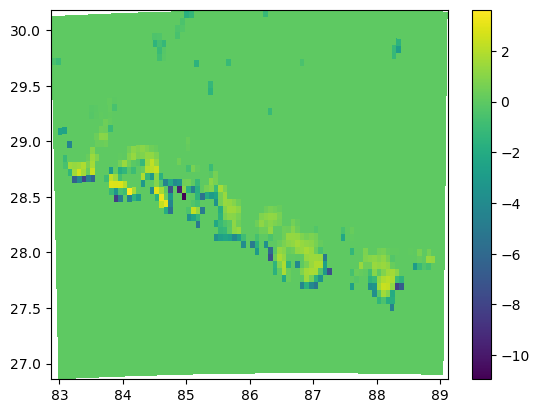

In [52]:
plt.pcolormesh(ds_lon, ds_lat, annual_mean)
plt.colorbar()
plt.show()

In [39]:
print(ds_lon.min().values, ds_lon.max().values)
print(ds_lat.min().values, ds_lat.max().values)

82.900475 89.08262
26.890814 30.154686


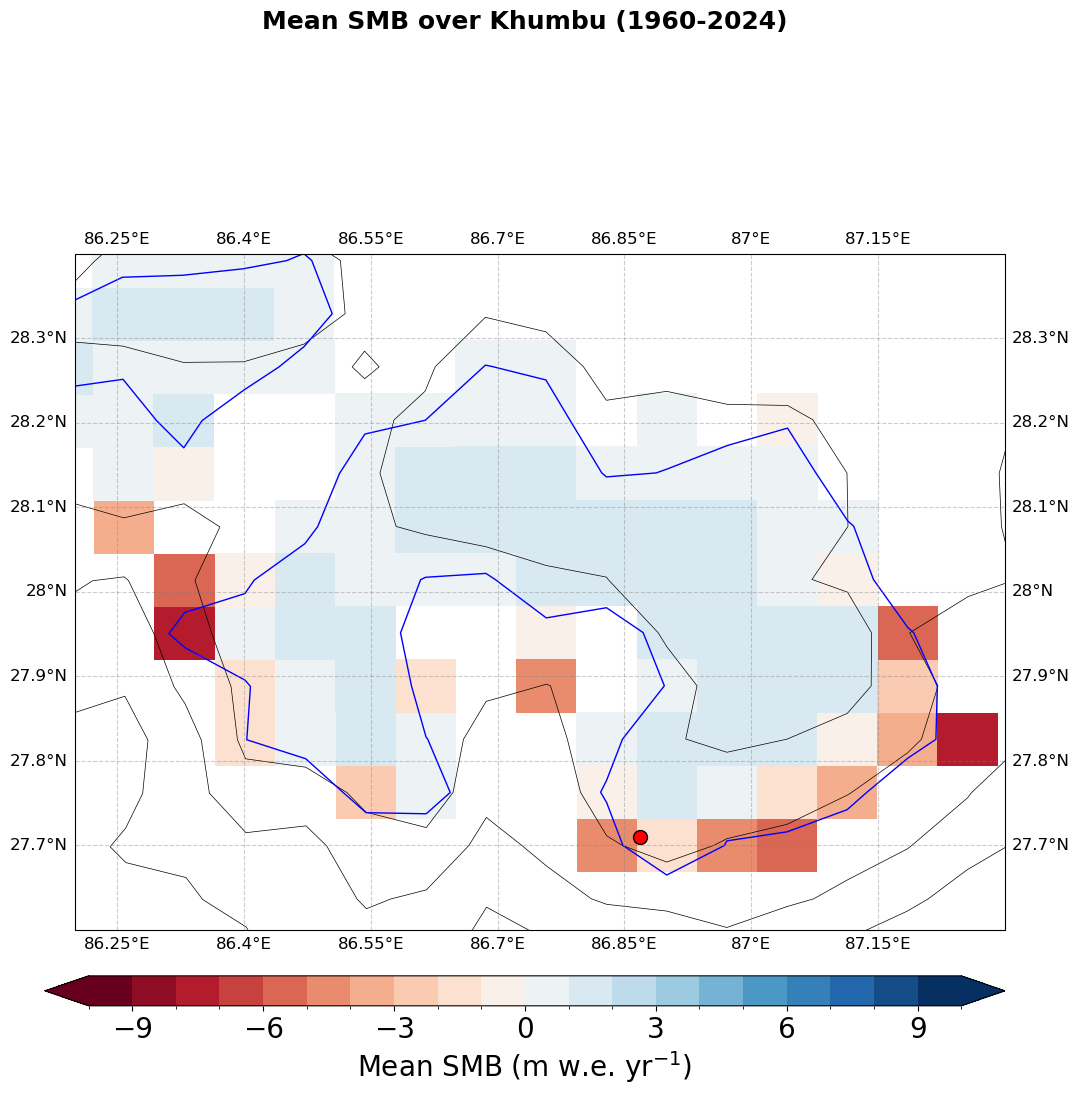

In [65]:
fig, ax = plt.subplots(figsize=(12,12),subplot_kw={'projection': ccrs.PlateCarree()}) # Utilisation de la projection plate carré

annual_mean_masked = annual_mean.where(annual_mean != 0) # Permet de mettre en blanc les valeurs strictement égales à 0

########## Color map ###############
vmin = -10
vmax = 10
step = 1
levels = np.arange(vmin, vmax + step, step)
base_cmap = plt.get_cmap("RdBu", len(levels)-1)
colors = base_cmap(np.arange(base_cmap.N))

cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, ncolors=len(colors))


############### Plot ###############
SH = ax.contour(ds_lon, ds_lat, ds_SH, 
           levels=np.arange(500, 7001, 1000), # Affichage des lignes de topographie
           colors="k", linewidths=0.5,
           transform=ccrs.PlateCarree())

#### Countour glaciers ####
ax.contour(ds_lon, ds_lat, ds_ICE, 
           levels=[ice_level], # Défini les lignes de contour des glaciers (bleu) où la grille dépasse la valeur de ice_level 
           colors="b", linewidths=1,
           transform=ccrs.PlateCarree())

#### SMB moyen par point de grille ####
im = ax.pcolormesh(ds_lon, ds_lat, annual_mean_masked,
                   cmap=cmap, norm=norm, # Affiche la couleur du % de glace
                   transform=ccrs.PlateCarree(),
                   shading="auto")

#### Mera Peak coord ####
ax.plot(merap_lon, merap_lat,  # Coord exact du Mera Peak
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

ax.set_extent([86.2, 87.3, 27.6, 28.4], crs=ccrs.PlateCarree()) # Défini les limites (lon, lat) du domaine observable 

gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

plt.suptitle(f"Mean SMB over Khumbu ({iyear}-{fyear})",fontsize=18,weight="bold")

############## Color bar ##################
cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("Mean SMB (m w.e. yr$^{-1}$)", fontsize=20)
cbar.ax.tick_params(labelsize=20)